# Part 3 — Final Results

This notebook presents the principal results from the fully executed `03_modeling.ipynb` workflow in a concise form. It contains no external file dependencies beyond the Python packages in `requirements.txt`. The complete model fitting, validation, ablation, uncertainty analysis, and diagnostics remain documented in Notebook 03.

**Primary metric:** mean absolute error (MAE) in euros per night.  
**Secondary metrics:** RMSE, R², and the proportion of predictions within €25 and €50.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 1. Main holdout comparison

The final candidate was selected using training-only cross-validation. The fixed test set was evaluated after model and target-scale selection. The PyTorch MLP is included as a neural-network benchmark, but the Random Forest remains the selected model.

,model,train_mae,test_mae,test_rmse,test_r2,within_25,within_50
0,"Random Forest — log target, no text",13.247,29.449,49.140,0.646,0.635,0.847
1,"PyTorch MLP — log target, no text",24.124,30.841,50.113,0.632,0.614,0.824
2,Random Forest — raw target,13.188,30.991,48.309,0.658,0.582,0.832
3,Gradient Boosting,30.365,32.137,50.884,0.621,0.569,0.823
4,Linear Regression,38.053,38.247,55.546,0.548,0.448,0.754
5,Ridge Regression,38.070,38.286,55.578,0.547,0.449,0.753
6,Median baseline,56.843,57.450,85.866,-0.080,0.325,0.619
7,Mean baseline,59.659,60.316,82.621,0.000,0.241,0.506


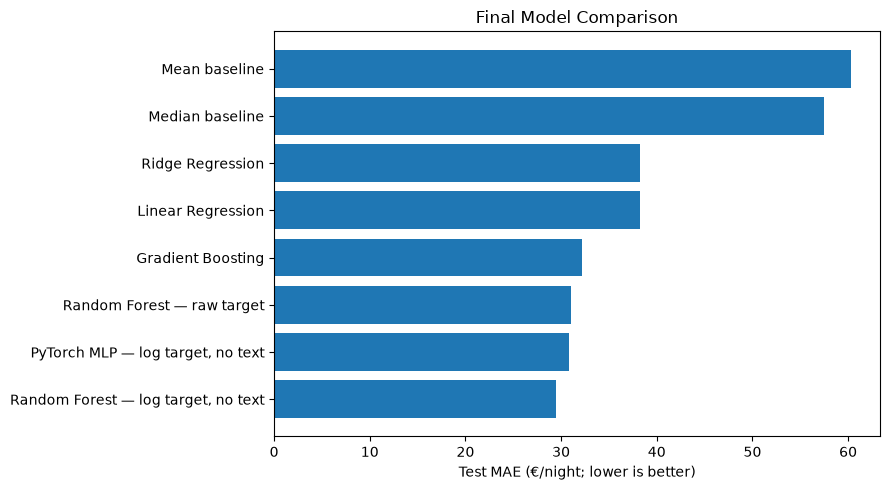

In [2]:
model_comparison = pd.DataFrame([
    {"model": "Random Forest — log target, no text", "train_mae": 13.247, "test_mae": 29.449, "test_rmse": 49.140, "test_r2": 0.646, "within_25": 0.635, "within_50": 0.847},
    {"model": "PyTorch MLP — log target, no text", "train_mae": 24.124, "test_mae": 30.841, "test_rmse": 50.113, "test_r2": 0.632, "within_25": 0.614, "within_50": 0.824},
    {"model": "Random Forest — raw target", "train_mae": 13.188, "test_mae": 30.991, "test_rmse": 48.309, "test_r2": 0.658, "within_25": 0.582, "within_50": 0.832},
    {"model": "Gradient Boosting", "train_mae": 30.365, "test_mae": 32.137, "test_rmse": 50.884, "test_r2": 0.621, "within_25": 0.569, "within_50": 0.823},
    {"model": "Linear Regression", "train_mae": 38.053, "test_mae": 38.247, "test_rmse": 55.546, "test_r2": 0.548, "within_25": 0.448, "within_50": 0.754},
    {"model": "Ridge Regression", "train_mae": 38.070, "test_mae": 38.286, "test_rmse": 55.578, "test_r2": 0.547, "within_25": 0.449, "within_50": 0.753},
    {"model": "Median baseline", "train_mae": 56.843, "test_mae": 57.450, "test_rmse": 85.866, "test_r2": -0.080, "within_25": 0.325, "within_50": 0.619},
    {"model": "Mean baseline", "train_mae": 59.659, "test_mae": 60.316, "test_rmse": 82.621, "test_r2": 0.000, "within_25": 0.241, "within_50": 0.506},
]).sort_values("test_mae").reset_index(drop=True)
display(model_comparison)

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = model_comparison.sort_values("test_mae", ascending=True)
ax.barh(plot_data["model"], plot_data["test_mae"])
ax.set_xlabel("Test MAE (€/night; lower is better)")
ax.set_title("Final Model Comparison")
fig.tight_layout()
plt.show()

### Final selected model

The selected model is the **Random Forest trained on `log1p(price)` without the six simple text-length features**. It achieved a test MAE of approximately **€29.45**, with **63.5%** of predictions within €25 and **84.7%** within €50.

The raw-target Random Forest has slightly better RMSE and R², so the log-target model is not universally better. It is selected because MAE was declared the primary metric before final test evaluation.

## 2. Training cross-validation and PyTorch MLP decision

In [3]:
candidate_cv = pd.DataFrame([
    {"candidate": "Random Forest — log target, no text", "mean_cv_mae": 30.287, "sd_cv_mae": 0.529, "mean_cv_rmse": 49.688, "mean_cv_r2": 0.623},
    {"candidate": "Random Forest — log target, full features", "mean_cv_mae": 30.316, "sd_cv_mae": 0.501, "mean_cv_rmse": 49.809, "mean_cv_r2": 0.621},
    {"candidate": "Random Forest — raw target, no text", "mean_cv_mae": 31.530, "sd_cv_mae": 0.506, "mean_cv_rmse": 48.946, "mean_cv_r2": 0.634},
    {"candidate": "PyTorch MLP 64-32 — log target, no text", "mean_cv_mae": 31.200, "sd_cv_mae": 0.298, "mean_cv_rmse": 50.558, "mean_cv_r2": 0.609},
    {"candidate": "Random Forest — raw target, full features", "mean_cv_mae": 31.716, "sd_cv_mae": 0.330, "mean_cv_rmse": 49.123, "mean_cv_r2": 0.631},
    {"candidate": "Gradient Boosting — Huber", "mean_cv_mae": 32.282, "sd_cv_mae": 0.398, "mean_cv_rmse": 50.702, "mean_cv_r2": 0.607},
    {"candidate": "Ridge — log target", "mean_cv_mae": 37.039, "sd_cv_mae": 0.228, "mean_cv_rmse": 58.767, "mean_cv_r2": 0.472},
    {"candidate": "Ridge — raw target", "mean_cv_mae": 38.592, "sd_cv_mae": 0.487, "mean_cv_rmse": 56.253, "mean_cv_r2": 0.516},
]).sort_values("mean_cv_mae").reset_index(drop=True)
display(candidate_cv)

,candidate,mean_cv_mae,sd_cv_mae,mean_cv_rmse,mean_cv_r2
0,"Random Forest — log target, no text",30.287,0.529,49.688,0.623
1,"Random Forest — log target, full features",30.316,0.501,49.809,0.621
2,"PyTorch MLP 64-32 — log target, no text",31.200,0.298,50.558,0.609
3,"Random Forest — raw target, no text",31.530,0.506,48.946,0.634
4,"Random Forest — raw target, full features",31.716,0.330,49.123,0.631
5,Gradient Boosting — Huber,32.282,0.398,50.702,0.607
6,Ridge — log target,37.039,0.228,58.767,0.472
7,Ridge — raw target,38.592,0.487,56.253,0.516


The MLP is worth including as a controlled benchmark because it uses PyTorch, nonlinear interactions, train-only standardization, AdamW, dropout, Huber loss, and early stopping. It is **not** worth replacing the Random Forest: its cross-validated MAE is about €0.91 higher. This result is consistent with the common advantage of tree ensembles on medium-sized tabular datasets, but it is an empirical result for this project rather than a general claim that neural networks cannot work on tabular data.

## 3. Stability across random train/test splits

,model,mean_mae,sd_mae,mean_rmse,mean_r2,within_25,within_50
0,"Random Forest — log target, no text",29.264,0.389,48.531,0.644,0.629,0.844
1,"PyTorch MLP — log target, no text",30.354,0.509,48.202,0.649,0.606,0.830
2,Random Forest — raw target,30.508,0.529,47.701,0.656,0.591,0.834
3,Gradient Boosting,31.756,0.624,50.162,0.620,0.572,0.827
4,Linear Regression,38.163,0.553,55.123,0.541,0.447,0.751
5,Ridge Regression,38.187,0.548,55.145,0.541,0.447,0.750


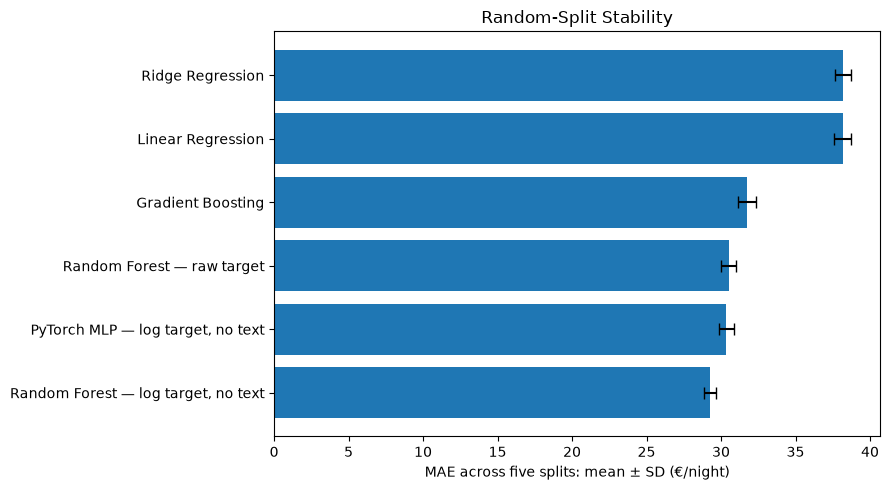

In [4]:
stability = pd.DataFrame([
    {"model": "Random Forest — log target, no text", "mean_mae": 29.264, "sd_mae": 0.389, "mean_rmse": 48.531, "mean_r2": 0.644, "within_25": 0.629, "within_50": 0.844},
    {"model": "PyTorch MLP — log target, no text", "mean_mae": 30.354, "sd_mae": 0.509, "mean_rmse": 48.202, "mean_r2": 0.649, "within_25": 0.606, "within_50": 0.830},
    {"model": "Random Forest — raw target", "mean_mae": 30.508, "sd_mae": 0.529, "mean_rmse": 47.701, "mean_r2": 0.656, "within_25": 0.591, "within_50": 0.834},
    {"model": "Gradient Boosting", "mean_mae": 31.756, "sd_mae": 0.624, "mean_rmse": 50.162, "mean_r2": 0.620, "within_25": 0.572, "within_50": 0.827},
    {"model": "Linear Regression", "mean_mae": 38.163, "sd_mae": 0.553, "mean_rmse": 55.123, "mean_r2": 0.541, "within_25": 0.447, "within_50": 0.751},
    {"model": "Ridge Regression", "mean_mae": 38.187, "sd_mae": 0.548, "mean_rmse": 55.145, "mean_r2": 0.541, "within_25": 0.447, "within_50": 0.750},
]).sort_values("mean_mae").reset_index(drop=True)
display(stability)

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = stability.sort_values("mean_mae", ascending=True)
ax.barh(plot_data["model"], plot_data["mean_mae"], xerr=plot_data["sd_mae"], capsize=4)
ax.set_xlabel("MAE across five splits: mean ± SD (€/night)")
ax.set_title("Random-Split Stability")
fig.tight_layout()
plt.show()

The MLP is stable across the five tested splits, but the log-target Random Forest remains better on the primary MAE criterion. The MLP and raw-target Random Forest have competitive RMSE/R² values, reinforcing that final model choice depends on how strongly large errors should be weighted.

## 4. Error penalty and Gradient Boosting loss

,loss,mean_mae,sd_mae,mean_rmse,mean_r2
0,Huber,31.756,0.624,50.162,0.620
1,Squared error,32.168,0.645,48.841,0.640
2,Absolute error,32.175,0.570,52.214,0.588


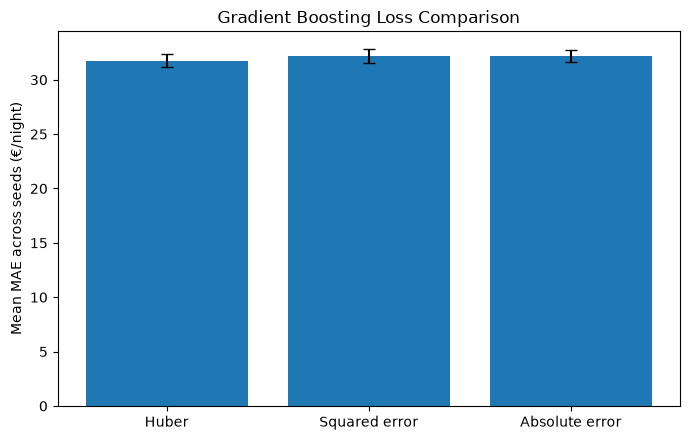

In [5]:
loss_comparison = pd.DataFrame([
    {"loss": "Huber", "mean_mae": 31.756, "sd_mae": 0.624, "mean_rmse": 50.162, "mean_r2": 0.620},
    {"loss": "Squared error", "mean_mae": 32.168, "sd_mae": 0.645, "mean_rmse": 48.841, "mean_r2": 0.640},
    {"loss": "Absolute error", "mean_mae": 32.175, "sd_mae": 0.570, "mean_rmse": 52.214, "mean_r2": 0.588},
]).sort_values("mean_mae").reset_index(drop=True)
display(loss_comparison)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(loss_comparison["loss"], loss_comparison["mean_mae"], yerr=loss_comparison["sd_mae"], capsize=4)
ax.set_ylabel("Mean MAE across seeds (€/night)")
ax.set_title("Gradient Boosting Loss Comparison")
fig.tight_layout()
plt.show()

Huber loss produced the best MAE, while squared error produced the best RMSE and R². Therefore, strongly penalizing large errors helps the extreme-error metrics but does not minimize the typical absolute euro error. MAE remains the primary measure because the project has no business cost function showing that a €50 error should count quadratically rather than proportionally.

## 5. Spatial and text ablations

,model,setting,mean_mae,sd_mae
2,Random Forest — log target,Full spatial,29.264,0.389
1,Random Forest — log target,Coarse location,30.820,0.685
0,Random Forest — log target,No spatial,31.315,0.664
5,Ridge Regression,Full spatial,38.187,0.548
4,Ridge Regression,Coarse location,38.730,0.545
3,Ridge Regression,No spatial,39.456,0.514


,model,setting,mean_mae,sd_mae
0,Random Forest — log target,Without simple text,29.264,0.389
1,Random Forest — log target,With simple text,29.329,0.418
3,Ridge Regression,With simple text,38.187,0.548
2,Ridge Regression,Without simple text,38.402,0.606


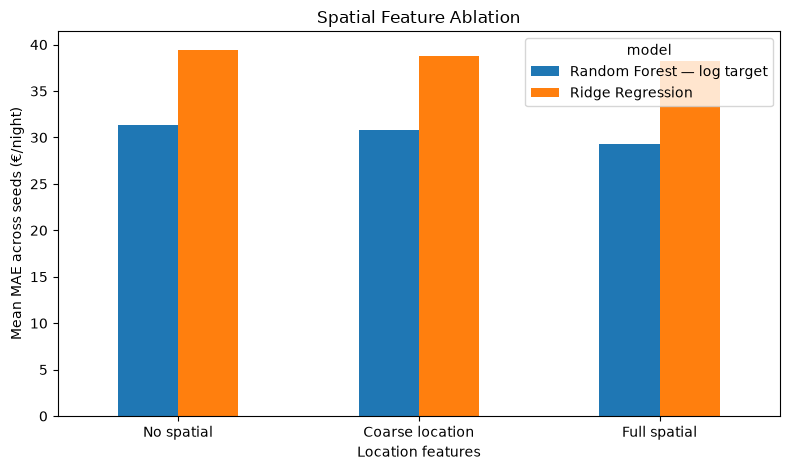

In [6]:
spatial = pd.DataFrame([
    {"model": "Random Forest — log target", "setting": "No spatial", "mean_mae": 31.315, "sd_mae": 0.664},
    {"model": "Random Forest — log target", "setting": "Coarse location", "mean_mae": 30.820, "sd_mae": 0.685},
    {"model": "Random Forest — log target", "setting": "Full spatial", "mean_mae": 29.264, "sd_mae": 0.389},
    {"model": "Ridge Regression", "setting": "No spatial", "mean_mae": 39.456, "sd_mae": 0.514},
    {"model": "Ridge Regression", "setting": "Coarse location", "mean_mae": 38.730, "sd_mae": 0.545},
    {"model": "Ridge Regression", "setting": "Full spatial", "mean_mae": 38.187, "sd_mae": 0.548},
])
text_ablation = pd.DataFrame([
    {"model": "Random Forest — log target", "setting": "Without simple text", "mean_mae": 29.264, "sd_mae": 0.389},
    {"model": "Random Forest — log target", "setting": "With simple text", "mean_mae": 29.329, "sd_mae": 0.418},
    {"model": "Ridge Regression", "setting": "Without simple text", "mean_mae": 38.402, "sd_mae": 0.606},
    {"model": "Ridge Regression", "setting": "With simple text", "mean_mae": 38.187, "sd_mae": 0.548},
])
display(spatial.sort_values(["model", "mean_mae"]))
display(text_ablation.sort_values(["model", "mean_mae"]))

fig, ax = plt.subplots(figsize=(8, 4.8))
pivot = spatial.pivot(index="setting", columns="model", values="mean_mae")
pivot.loc[["No spatial", "Coarse location", "Full spatial"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Mean MAE across seeds (€/night)")
ax.set_xlabel("Location features")
ax.set_title("Spatial Feature Ablation")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

Full spatial information improves both Ridge and Random Forest prediction. The difference between the Random Forest with no location and full spatial features is approximately **€2.05 MAE**, larger than the split-to-split standard deviations.

The six simple text-length and word-count features add no meaningful Random Forest improvement. This conclusion applies only to that shallow representation; TF-IDF or language embeddings were not tested.

## 6. Error analysis for the selected model

In [7]:
price_band_errors = pd.DataFrame([
    {"price_band": "Q1: lowest", "n": 481, "mae": 14.409, "median_ae": 10.663, "within_25": 0.817, "within_50": 0.975},
    {"price_band": "Q2", "n": 437, "mae": 17.878, "median_ae": 14.415, "within_25": 0.778, "within_50": 0.959},
    {"price_band": "Q3", "n": 459, "mae": 23.561, "median_ae": 18.686, "within_25": 0.625, "within_50": 0.915},
    {"price_band": "Q4: highest", "n": 458, "mae": 62.184, "median_ae": 43.873, "within_25": 0.319, "within_50": 0.539},
])
room_type_errors = pd.DataFrame([
    {"room_type": "Entire home/apt", "n": 1320, "mae": 33.527, "median_ae": 21.282},
    {"room_type": "Hotel room", "n": 18, "mae": 47.795, "median_ae": 21.521},
    {"room_type": "Private room", "n": 478, "mae": 18.339, "median_ae": 11.663},
    {"room_type": "Shared room", "n": 19, "mae": 8.236, "median_ae": 6.597},
])
display(price_band_errors)
display(room_type_errors)

,price_band,n,mae,median_ae,within_25,within_50
0,Q1: lowest,481,14.409,10.663,0.817,0.975
1,Q2,437,17.878,14.415,0.778,0.959
2,Q3,459,23.561,18.686,0.625,0.915
3,Q4: highest,458,62.184,43.873,0.319,0.539


,room_type,n,mae,median_ae
0,Entire home/apt,1320,33.527,21.282
1,Hotel room,18,47.795,21.521
2,Private room,478,18.339,11.663
3,Shared room,19,8.236,6.597


The main failure mode is the highest-price quartile, where MAE rises to approximately €62.18. The log target improves typical errors but compresses the upper tail and tends to underpredict expensive listings. The hotel-room and shared-room subgroup estimates are based on very small test counts and should not be generalized confidently.

## 7. Feature importance and uncertainty

,feature,increase_in_mae
0,minimum_nights,12.975
1,accommodates,9.754
2,room_type_Private room,6.327
3,bedrooms,6.059
4,distance_to_center_km,3.815
5,bathrooms_parsed,2.808
6,host_listings_count,2.142
7,room_type_Shared room,1.244
8,instant_bookable,1.210
9,availability_60,1.010


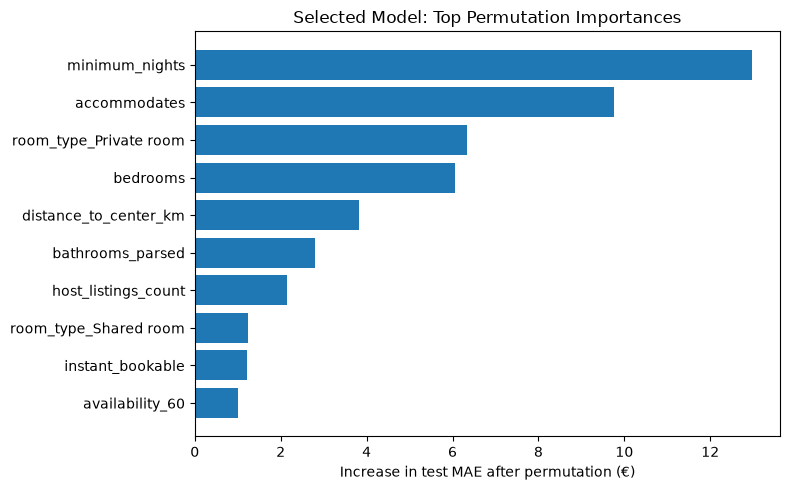

,metric,estimate,lower_95%,upper_95%
0,MAE,29.449,27.753,31.297
1,RMSE,49.140,45.022,53.512


In [8]:
feature_importance = pd.DataFrame([
    {"feature": "minimum_nights", "increase_in_mae": 12.975},
    {"feature": "accommodates", "increase_in_mae": 9.754},
    {"feature": "room_type_Private room", "increase_in_mae": 6.327},
    {"feature": "bedrooms", "increase_in_mae": 6.059},
    {"feature": "distance_to_center_km", "increase_in_mae": 3.815},
    {"feature": "bathrooms_parsed", "increase_in_mae": 2.808},
    {"feature": "host_listings_count", "increase_in_mae": 2.142},
    {"feature": "room_type_Shared room", "increase_in_mae": 1.244},
    {"feature": "instant_bookable", "increase_in_mae": 1.210},
    {"feature": "availability_60", "increase_in_mae": 1.010},
])
display(feature_importance)

fig, ax = plt.subplots(figsize=(8, 5))
plot_data = feature_importance.sort_values("increase_in_mae")
ax.barh(plot_data["feature"], plot_data["increase_in_mae"])
ax.set_xlabel("Increase in test MAE after permutation (€)")
ax.set_title("Selected Model: Top Permutation Importances")
fig.tight_layout()
plt.show()

bootstrap_intervals = pd.DataFrame([
    {"metric": "MAE", "estimate": 29.449, "lower_95%": 27.753, "upper_95%": 31.297},
    {"metric": "RMSE", "estimate": 49.140, "lower_95%": 45.022, "upper_95%": 53.512},
])
display(bootstrap_intervals)

Permutation importance describes predictive contribution, not causal effect. Correlated features can divide or mask importance. The bootstrap intervals quantify uncertainty for the fixed holdout prediction pairs but do not include future market shift or uncertainty caused by the preprocessing decisions made before splitting.

## 8. Final conclusions and limitations

1. All trained models outperform the constant baselines, and nonlinear models outperform the linear models.
2. The final log-target Random Forest provides the best training-selected MAE and stable five-seed performance.
3. The PyTorch MLP is competitive and stable, but it does not improve the primary metric enough to replace the Random Forest.
4. Full spatial information provides a meaningful predictive gain.
5. The current simple text summaries provide little additional value.
6. Huber loss balances ordinary and large prediction errors; squared error improves RMSE but not MAE.
7. Expensive listings remain the largest source of error.

### Preprocessing limitation

Some cleaning and feature-preparation steps, including median imputation, categorical encoding, and the price-outlier threshold, were calculated before the train–test split. Although model fitting, hyperparameter selection, scaling, and neural-network training were restricted to the training data, this preprocessing order may introduce a small optimistic bias. Future work should place all data-dependent preprocessing inside the cross-validation and training pipelines.